# Análise de Fraudes em Transações Financeiras

Projeto de aprendizado com o objetivo realizar uma análise de transações financeiras utilizando Python, buscando identificar padrões relacionados a transações fraudulentas.

Os dados serão carregados de uma fonte externa e analisados utilizando bibliotecas como Pandas, NumPy, Matplotlib, Seaborn e Scikit-learn.

Durante o projeto serão realizadas etapas de exploração, visualização e preparação dos dados, além da criação de um modelo simples de Machine Learning para auxiliar na identificação de possíveis fraudes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Carregamento dos Dados

O conjunto de dados utilizado contém informações sobre transações realizadas com cartões de crédito.

Os dados são carregados diretamente de uma fonte externa em formato CSV utilizando a biblioteca Pandas.

In [2]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Exploração Inicial dos Dados

Antes de analisar os dados, é importante conhecer a estrutura dos conjuntos, verificando sua dimensão, tipos de variáveis e possíveis valores ausentes.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [5]:
df[df.duplicated()]["Class"].value_counts()

Class
0    1062
1      19
Name: count, dtype: int64

In [6]:
df = df.drop_duplicates()

### Observações iniciais

O conjunto de dados possui 284.807 transações e 31 variáveis. No entanto, apresentou 1081 células duplicadas.

O conjunto de dados não apresenta valores nulos, mas durante análises de duplicatas foram encontradas algumas células iguais, que foram removidas para não prejudicar as análises.

## Análise das Transações Fraudulentas

A variável `Class` identifica se uma transação é legítima ou fraudulenta:

- `0` representa uma transação legítima;
- `1` representa uma transação fraudulenta.

In [7]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [8]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

### Distribuição das classes

Das 283.726 transações analisadas:

- 283.253 são legítimas, representando aproximadamente 99,83% dos dados;
- 473 são fraudulentas, representando aproximadamente 0,16% dos dados.

Essa diferença demonstra que o conjunto de dados é fortemente desbalanceado, característica que deverá ser considerada posteriormente durante a criação e avaliação do modelo de Machine Learning.

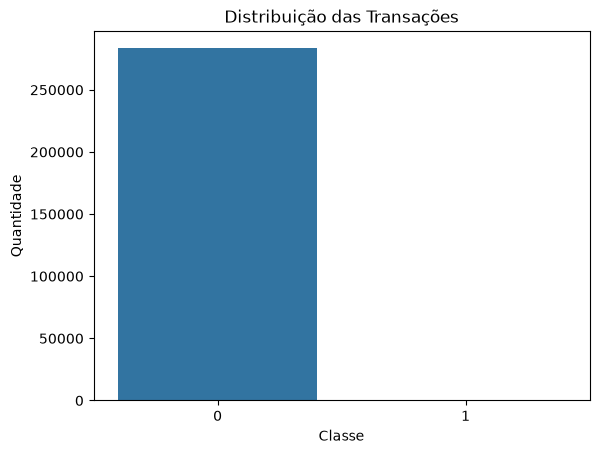

In [9]:
sns.countplot(data=df, x="Class")

plt.title("Distribuição das Transações")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

plt.show()

## Análise dos Valores das Transações

Nesta etapa, serão analisados os valores das transações e comparadas as diferenças entre operações legítimas e fraudulentas.

In [10]:
df["Amount"].describe()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

In [11]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


### Observações sobre os valores

As transações fraudulentas (valor de `Class` igual a 1) apresentam valor médio superior ao das transações legítimas (valor de `Class` igual a 0), aproximadamente 123,87 contra 88,41.
Porém a mediana das fraudes é menor: 9,82 contra 22,00 nas transações legítimas. Isso indica que muitas fraudes possuem valores baixos, enquanto algumas transações de maior valor elevam a média. 

Também há valores extremos no conjunto de dados, principalmente entre as transações legítimas.
O boxplot mostra que as transações fraudulentas apresentam uma mediana de valor menor que as transações legítimas, apesar de possuírem uma distribuição mais ampla.
Isso reforça que o apenas o valor da transação não é suficiente para determinar se uma operação é fraudulenta.

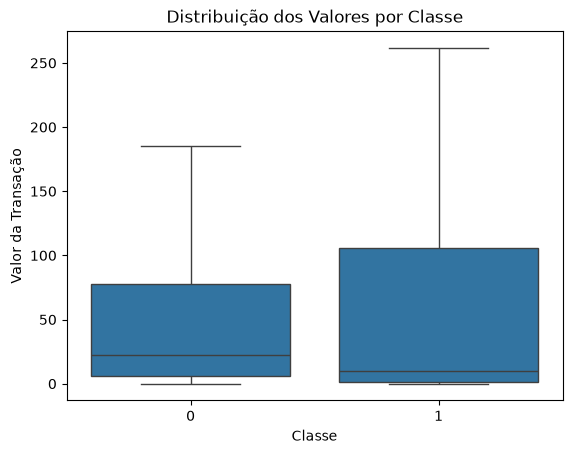

In [12]:
sns.boxplot(data=df, x="Class", y="Amount", showfliers=False)

plt.title("Distribuição dos Valores por Classe")
plt.xlabel("Classe")
plt.ylabel("Valor da Transação")

plt.show()

## Preparação dos Dados para Machine Learning

Nesta etapa, os dados serão separados entre variáveis de entrada e variável alvo, preparando o conjunto para o treinamento de um modelo de classificação.

A coluna `Class` será utilizada como variável alvo, indicando se a transação é legítima (`0`) ou fraudulenta (`1`).

In [13]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("X:", X.shape)
print("y:", y.shape)

X: (283726, 30)
y: (283726,)


## Divisão entre Treino e Teste

Os dados serão divididos em dois conjuntos:

- **Treino:** utilizado para o modelo aprender os padrões das transações;
- **Teste:** utilizado para avaliar o desempenho do modelo em dados que não foram utilizados durante o treinamento.

Será feita uma divisão de 80% para treino e 20% para teste.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X treino:", X_train.shape)
print("X teste:", X_test.shape)
print("y treino:", y_train.shape)
print("y teste:", y_test.shape)

X treino: (226980, 30)
X teste: (56746, 30)
y treino: (226980,)
y teste: (56746,)


## Padronização dos Dados

As variáveis `Time` e `Amount` possuem escalas diferentes das demais características do conjunto de dados.

Foi utilizado o `StandardScaler` para padronizar essas variáveis. O scaler foi ajustado apenas com os dados de treino e depois aplicado aos dados de teste, evitando que informações do conjunto de teste influenciassem o treinamento.

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[["Time", "Amount"]] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_test_scaled[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

X_train_scaled[["Time", "Amount"]].head()

,Time,Amount
226238,1.045499,-0.229434
134253,-0.298690,-0.331197
186465,0.678397,-0.298809
149493,-0.074929,-0.289247
18461,-1.376728,-0.261985


## Treinamento do Modelo

Para classificar as transações, será utilizado o modelo de Regressão Logística.

Como o conjunto de dados possui uma quantidade muito maior de transações legítimas do que fraudulentas, será utilizado o parâmetro `class_weight="balanced"` para dar maior equilíbrio à importância das duas classes durante o treinamento.

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

## Avaliação do Modelo

Após o treinamento, o modelo será avaliado utilizando diferentes métricas. Uma delas é a acurácia, que representa a proporção total de previsões corretas. Entretanto, devido ao forte desbalanceamento entre transações legítimas e fraudulentas, essa métrica não deve ser analisada isoladamente.

Também serão utilizadas:

- **Precision:** indica quantas das transações classificadas como fraude realmente eram fraudulentas;
- **Recall:** indica quantas das fraudes existentes foram corretamente identificadas pelo modelo;
- **F1-score:** representa um equilíbrio entre Precision e Recall;
- **Matriz de Confusão:** permite visualizar os acertos e erros do modelo para cada classe.

Acurácia: 0.9752

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



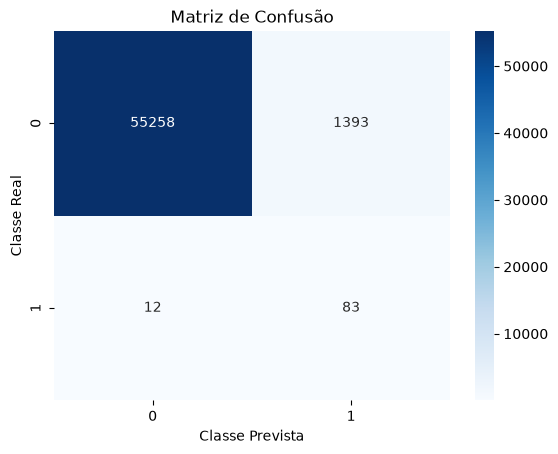

In [17]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)

print(f"Acurácia: {accuracy:.4f}\n")

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusão")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.show()

### Análise dos Resultados

O modelo apresentou acurácia de aproximadamente 97,52%.
Para as transações fraudulentas, o Recall foi de 0,87, indicando que o modelo conseguiu identificar 83 das 95 fraudes presentes no conjunto de teste.

Entretanto, a Precision para fraudes foi de apenas 0,06. Apesar de identificar grande parte das fraudes, o modelo também classificou 1.393 transações legítimas como fraudulentas.
Esse resultado demonstra o desafio causado pelo forte desbalanceamento do conjunto de dados e reforça que a acurácia, isoladamente, não é suficiente para avaliar modelos de detecção de fraude.

## Conclusão

Durante a exploração dos dados, foi identificado um forte desbalanceamento entre as classes, com a grande maioria das transações sendo legítimas e apenas uma pequena partecorrespondendo a fraudes. Também foram analisados os valores das transações e removidas linhas duplicadas antes da preparação dos dados para o modelo.

Após a divisão entre treino e teste e a padronização das variáveis `Time` e `Amount`, foi utilizado um modelo de Regressão Logística para classificar as transações.

O modelo apresentou acurácia de aproximadamente 97,52% e Recall de 0,87 para a classe de fraude, conseguindo identificar 83 das 95 fraudes presentes no conjunto de teste. Entretanto, a Precision para fraudes foi baixa, indicando uma quantidade elevada de falsos positivos.

Os resultados mostram que, em problemas com dados desbalanceados, métricas como Precision, Recall e F1-score são mais importantes para avaliar o comportamento do modelo do que a acurácia analisada isoladamente.